# MNSol Database: SMILES Validation & Molecule Identity Audit

The [MNSol database](https://comp.chem.umn.edu/mnsol/) contains ~2,400 experimental solvation free energies. Each entry links a common compound name to an XYZ coordinate file. Before using MNSol, four potential data-quality issues must be checked:

| # | Question | Test |
|---|----------|------|
| 1 | Does the XYZ geometry match its common name? | `nx_isomorphic`, `offmol_isomorphic` |
| 2 | Does a hand-curated `name → SMILES` map agree with the XYZ? | `formula_consistent` + graph isomorphism |
| 3 | Does `tmos` bond perception reproduce the reference SMILES (up to resonance)? | `offmol_isomorphic` deep-dive |
| 4 | Does `Molecule.from_iupac()` (OpenEye) produce the right structure for common names? | `smiles_agree_iupac_nx/iso` |

**Bottom line up front:** most entries are fine, but a meaningful minority have name/structure mismatches. The cells below quantify each issue and identify the offending entries.

## What is `tmos`?

[`tmos`](https://github.com/openforcefield/tmos) (Transition Metal Oxidation State) is an informal internal toolset from the Open Force Field Initiative for analyzing transition metal complexes. In this notebook it is used for one specific capability: **converting raw XYZ coordinate data into a chemically complete RDKit molecule with bond orders and formal charges**, without needing a SMILES string or any pre-existing connectivity.

The relevant call chain is:

```python
import tmos

rdmol = tmos.build_rdmol.xyz_to_rdkit(symbols, coordinates, ignore_scale=True)
rdmol = tmos.build_rdmol.determine_bonds(rdmol, charge=charge)
```

1. `xyz_to_rdkit` — places atoms at their 3D positions and infers rough connectivity from interatomic distances (covalent radii heuristic).
2. `determine_bonds` — assigns integer bond orders and formal charges consistent with valence rules, given the net molecular charge.

This lets us independently reconstruct a molecule from the XYZ file stored in MNSol and compare it against a reference SMILES — the core of the validation done in this notebook.

> **Disclaimer:** `tmos` is described as informal internal tooling with no versioning or support guarantees.

In [1]:
import os
import csv
import json
from collections import defaultdict
import re

from tqdm.auto import tqdm
import numpy as np
import polars as pl
import networkx as nx
from openff.toolkit import Molecule
import pathlib
from rdkit import Chem
from openbabel import openbabel as ob
import periodictable
from deepdiff import DeepDiff

try:
    from openeye import oechem  # for from_iupac
except ImportError:
    oechem = None

import tmos

if oechem is not None:
    try:
        _oe_null_stream = oechem.oeofstream()
        _oe_null_stream.open(os.devnull)
        oechem.OEThrow.SetOutputStream(_oe_null_stream)
        oechem.OEThrow.SetLevel(oechem.OEErrorLevel_Error)  # hide warnings/info
    except Exception:
        pass

# Suppress all OpenBabel output including stereochemistry errors
ob.obErrorLog.SetOutputLevel(0)
ob.obErrorLog.StopLogging()
os.environ["BABEL_SILENCE"] = "1"

# Update this path to point to your local copy of MNSol_alldata.txt
#mnsol_file = pathlib.Path("path/to/MNSolDatabase/MNSol_alldata.txt")
mnsol_file = pathlib.Path("/Users/jenniferclark/OMSF/OpenFE/BenchmarkRepo/MNSolDatabase_v2012/MNSol_alldata.txt")


## Helper Utilities

Two formula-comparison helpers underpin the consistency checks:

- **`formula_dict_from_string(formula)`** — parses the molecular formula stored in the MNSol data file (handles both `H7C6N1CL1`-style and conventional `CCl4`-style strings).
- **`formula_dict_from_rdkit(mol)`** — counts elements in an RDKit `Mol` object.
- **`check_formula_consistency(formula, rdmol, charge)`** — compares the two; if they differ by exactly ±1 H and the recorded charge is ±1, the entry is a protonation-state variant rather than a genuine mismatch.

In [2]:
with open("mnsol-name-to-smiles.json") as f:
    NAME_TO_SMILES = json.load(f)

def get_offmol(name: str) -> Molecule | None:
    """Get OpenFF Molecule"""
    
    smiles = NAME_TO_SMILES[name]

    offmol = Molecule.from_smiles(smiles, name=name, allow_undefined_stereo=True) if name in NAME_TO_SMILES else None
        
    return offmol

def read_coordinates(filehandle: str, path: pathlib.Path):
    """Get coordinates and elemental symbols for a molecule

    Parameters
    ----------
    filehandle : str
        File handle provided in MNSol_alldata.txt
    path : pathlib.Path
        Path to MNSol_alldata.txt

    Returns
    -------
    coordinates : list[list[float]]
        Coordinates of molecule
    elements : list[str]
        List of atomic numbers.

    Raises
    ------
    FileNotFoundError
    """
    filename = path.parent / "all_solutes" / f"{filehandle}.xyz"
    if not filename.exists():
        raise FileNotFoundError(f"File {filename} is missing!")
    
    with open(filename, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]
        charge = int(lines[1].split()[0])
        # Skip first two non-empty line
        lines = lines[2:]
        
        coordinates = []
        elements = []
        
        for line in lines:
            parts = line.split()
            if len(parts) >= 4:
                elements.append(parts[0])
                coordinates.append([float(parts[1]), float(parts[2]), float(parts[3])])
        
    return coordinates, elements, charge


def formula_dict_from_string(formula):
    if not formula:
        return {}
    # Try the "letters followed by explicit counts" form first (e.g. H7C6N1CL1, H2O1F1)
    tokens = re.findall(r'([A-Za-z]{1,2})(\d+)', formula)
    if tokens and ''.join(f"{s}{n}" for s, n in tokens) == formula:
        return {s.capitalize(): int(n) for s, n in tokens}
    # Fallback to conventional parsing (e.g. H2O, CCl4, NaCl)
    out = {}
    pos = 0
    for m in re.finditer(r'([A-Z][a-z]?)(\d*)', formula):
        if m.start() != pos:
            raise ValueError(f"Could not parse formula: {formula!r}")
        sym, cnt = m.groups()
        sym = sym.capitalize()
        out[sym] = out.get(sym, 0) + (int(cnt) if cnt else 1)
        pos = m.end()
    if pos != len(formula):
        raise ValueError(f"Could not parse formula: {formula!r}")
    return out

def formula_dict_from_offmol(offmol):
    """Return element counts (e.g. {'C': 6, 'H': 7, 'Cl': 1}) for an OpenFF Molecule (accepts RDKit Mol too)."""
    counts = defaultdict(int)

    # Expect OpenFF Molecule-like object with .atoms
    atoms = getattr(offmol, "atoms", None)
    if atoms is None:
        raise TypeError("Unsupported molecule object: expected OpenFF Molecule or rdkit.Chem.Mol")

    for a in atoms:
        z = getattr(a, "atomic_number", None)
        if z is None:
            elem = getattr(a, "element", None)
            if elem is not None:
                z = getattr(elem, "atomic_number", None)
        if z is not None:
            sym = periodictable.elements[int(z)].symbol
        else:
            # fall back to any available symbol-like attribute
            sym = getattr(a, "element_symbol", None) or getattr(a, "symbol", None)
            if sym is None:
                raise TypeError(f"Cannot determine element for atom: {a!r}")
            sym = str(sym).capitalize()
        counts[sym] += 1

    return dict(counts)

def formula_dict_from_rdkit(offmol):
    """Return element counts (e.g. {'C': 6, 'H': 7, 'Cl': 1}) for an RDKit Mol."""
    if not isinstance(offmol, Chem.Mol):
        raise TypeError(
            f"Unsupported molecule type {type(offmol)!r} in formula_dict_from_rdkit; expected an rdkit.Chem.Mol."
        )

    counts = defaultdict(int)
    for a in offmol.GetAtoms():
        sym = periodictable.elements[a.GetAtomicNum()].symbol
        counts[sym] += 1
    return dict(counts)

def check_formula_consistency(formula, rdmol, charge):
    x1 = formula_dict_from_rdkit(rdmol)
    x2 = formula_dict_from_string(formula)
    if x1 is None or x2 is None:
        raise ValueError(
            f"Failed to compute element counts for formula={formula!r}, "
            f"charge={charge!r}, rdmol_type={type(rdmol).__name__}. "
            "Upstream helper returned None."
        )

    dd = DeepDiff(x1, x2)
    flag_skip = False

    if dd and charge in (-1, 1):
        all_keys = set(x1.keys()) | set(x2.keys())
        non_h_equal = all(
            x1.get(elem, 0) == x2.get(elem, 0)
            for elem in all_keys
            if elem != "H"
        )
        if non_h_equal:
            adjusted_x1 = dict(x1)
            h_count = adjusted_x1.get("H", 0)
            if charge == -1:
                adjusted_x1["H"] = h_count - 1
            elif charge == 1:
                adjusted_x1["H"] = h_count + 1
            dd = DeepDiff(adjusted_x1, x2)
            if not dd:
                flag_skip = True

    return dd, flag_skip


In [3]:
# ── individual row-level test functions ───────────────────────────────────────

def get_xyz_rdmol(filehandle):
    coordinates, elements, charge = read_coordinates(filehandle, mnsol_file)
    symbols = [periodictable.elements[int(num)].symbol for num in elements]

    rdmol = tmos.build_rdmol.xyz_to_rdkit(symbols, coordinates, ignore_scale=True)
    rdmol = tmos.build_rdmol.determine_bonds(rdmol, charge=charge)
    return rdmol

def test_is_radical(solute_name: str) -> bool:
    return "radical" in solute_name

def test_name_in_smiles_dict(name: str) -> bool:
    return name in NAME_TO_SMILES

def test_get_offmol(solute_name: str):
    """Return 'success' or str(e)[:80].  None when solute_name not in SMILES dict."""
    if get_offmol is None or solute_name not in NAME_TO_SMILES:
        return None
    try:
        get_offmol(solute_name)
        return "success"
    except Exception as e:
        return str(e)


def test_formula_consistent(formula: str, solute_name: str, filehandle: str):
    """Return (True/False/None, adapted_name).

    True  -  formula matches SMILES mol (possibly after ±1 H proton adaptation).
    False -  mismatch that cannot be explained by protonation state.
    None  -  prerequisite failed (no SMILES entry or coordinates unreadable).
    adapted_name is solute_name with '_deprotonated' / '_protonated' suffix when applicable.
    """
    if read_coordinates is None or solute_name not in NAME_TO_SMILES:
        return None, solute_name
    try:
        solute_rdkit = Chem.MolFromSmiles(NAME_TO_SMILES[solute_name])
        solute_rdkit = Chem.AddHs(solute_rdkit)
    except Exception:
        return None, solute_name
    try:
        _, _, charge = read_coordinates(filehandle, mnsol_file)
    except Exception:
        return None, solute_name
    adapted_name = solute_name
    try:
        diff, flag_skip = check_formula_consistency(formula, solute_rdkit, charge)
        if flag_skip and len(diff) == 0:
            if charge == -1:
                adapted_name = solute_name + "_deprotonated"
            elif charge == 1:
                adapted_name = solute_name + "_protonated"
            return True, adapted_name
        elif len(diff) == 0:
            return True, adapted_name
        else:
            return False, adapted_name
    except Exception:
        return False, adapted_name


def test_xyz_to_rdkit_result(filehandle: str, rdmol_dict: dict):
    """Return 'success' or str(e)[:80].  None when coordinates are unreadable."""
    if read_coordinates is None:
        return None
    try:
        rdmol = get_xyz_rdmol(filehandle)
        rdmol_dict[filehandle] = rdmol
        return "success"
    except Exception as e:
        return str(e)


def test_nx_isomorphic(solute_name: str, filehandle: str, rdmol_dict: dict):
    """Return True/False/None (None when a prerequisite step fails)."""
    if get_offmol is None or solute_name not in NAME_TO_SMILES:
        return None
    try:
        solute_offmol = get_offmol(solute_name)
    except Exception:
        return None
    try:
        if filehandle in rdmol_dict:
            rdmol = rdmol_dict[filehandle]
        else:
            rdmol = get_xyz_rdmol(filehandle)
    except Exception:
        return None
    try:
        nx_smiles = tmos.graph_mapping.mol_to_graph(solute_offmol.to_rdkit())
        nx_xyz    = tmos.graph_mapping.mol_to_graph(rdmol)
        node_match = nx.algorithms.isomorphism.categorical_node_match("symbol", None)
        gm = nx.algorithms.isomorphism.GraphMatcher(nx_smiles, nx_xyz, node_match=node_match)
        return gm.is_isomorphic()
    except Exception:
        return None


def test_offmol_isomorphic(solute_name: str, filehandle: str, rdmol_dict: dict):
    """Return True/False/None (None when a prerequisite step fails)."""
    if get_offmol is None or solute_name not in NAME_TO_SMILES:
        return None
    try:
        solute_offmol = get_offmol(solute_name)
    except Exception:
        return None
    try:
        if filehandle in rdmol_dict:
            rdmol = rdmol_dict[filehandle]
        else:
            rdmol = get_xyz_rdmol(filehandle)
        solute_offmol0 = Molecule.from_rdkit(rdmol)
    except Exception:
        return None
    try:
        flag, _ = Molecule.are_isomorphic(
            solute_offmol, solute_offmol0,
            return_atom_map=True,
            aromatic_matching=True,
        #    formal_charge_matching=False,
        #    bond_order_matching=False,
            atom_stereochemistry_matching=False,
            bond_stereochemistry_matching=False,
        )
        return flag
    except Exception:
        return None

def test_name_iupac_nx(solute_name: str):
    """Return True/False/None (None when a prerequisite step fails)."""
    if oechem is None or get_offmol is None or solute_name not in NAME_TO_SMILES:
        return None
    try:
        solute_offmol = get_offmol(solute_name)
    except Exception:
        return None
    try:
        mol = Molecule.from_iupac(solute_name)
    except Exception:
        return None
    try:
        nx_smiles = tmos.graph_mapping.mol_to_graph(solute_offmol.to_rdkit())
        nx_xyz    = tmos.graph_mapping.mol_to_graph(mol.to_rdkit())
        node_match = nx.algorithms.isomorphism.categorical_node_match("symbol", None)
        gm = nx.algorithms.isomorphism.GraphMatcher(nx_smiles, nx_xyz, node_match=node_match)
        return gm.is_isomorphic()
    except Exception:
        return None


def test_name_iupac_iso(solute_name: str):
    """Return True/False/None (None when a prerequisite step fails)."""
    if oechem is None or get_offmol is None or solute_name not in NAME_TO_SMILES:
        return None
    try:
        solute_offmol = get_offmol(solute_name)
    except Exception:
        return None
    try:
        mol = Molecule.from_iupac(solute_name)
    except Exception:
        return None
    try:
        flag, _ = Molecule.are_isomorphic(
            solute_offmol, mol,
            return_atom_map=True,
            aromatic_matching=True,
        #    formal_charge_matching=False,
        #    bond_order_matching=False,
            atom_stereochemistry_matching=False,
            bond_stereochemistry_matching=False,
        )
        return flag
    except Exception:
        return None

## Per-Row Test Functions

Each function below tests one property of a single MNSol entry and returns a result that can be stored in a dataframe column. `None` means "prerequisite failed — skip" rather than a genuine failure.

| Function | What it checks | Keys tested |
|----------|---------------|-------------|
| `test_formula_consistent` | SMILES heavy-atom formula matches XYZ element list | `formula_consistent` |
| `test_xyz_to_rdkit_result` | `tmos` can build an RDKit mol from the XYZ (bond perception) | `xyz_to_rdkit_result` |
| `test_nx_isomorphic` | SMILES graph == XYZ graph (element-only, no bond orders) | `nx_isomorphic` |
| `test_offmol_isomorphic` | SMILES graph == XYZ graph (with bond orders & formal charges via OpenFF) | `offmol_isomorphic` |
| `test_name_iupac_nx/iso` | IUPAC lookup of the common name gives the same structure as the reference SMILES | `smiles_agree_iupac_*` |

> **Why two isomorphism checks?** The simple graph test (`nx_isomorphic`) catches element/connectivity mismatches. The OpenFF test (`offmol_isomorphic`) additionally catches bond-order and formal-charge discrepancies—for example, a `tmos` molecule where a carboxylate C=O vs C-O is assigned differently than the reference SMILES.

## Full Dataset Survey

`test_mnsol()` iterates over every `type=abs` row in `MNSol_alldata.txt`, runs each test function above, and returns a Polars dataframe with one row per (solute, solvent) system. The final print block summarises pass/fail counts for every check.

In [4]:
def test_mnsol():
    import polars as pl

    rows = []
    found_names = set()
    rdmols_dict = {}
    with mnsol_file.open("r", encoding="utf-8", errors="replace") as fh:
        total = max(sum(1 for _ in fh) - 1, 0)
        fh.seek(0)

        reader = csv.DictReader(fh, delimiter="\t")
        for row in tqdm(reader, total=total):
            if not row or not row.get("FileHandle"):
                continue

            key          = f"mnsol-{int(row.get('No.')):04d}"
            filehandle   = row.get("FileHandle").strip().strip('"')
            solute_name  = row.get("SoluteName").strip().strip('"')
            solvent_name = row.get("Solvent").strip().strip('"')
            formula      = row.get("Formula").strip().strip('"')
            group        = row.get("Level1").strip().strip('"')
            charge       = row.get("Charge").strip().strip('"')
            found_names.add(solvent_name)
            found_names.add(solute_name)
            if row.get("type") != "abs": # 102 molecules in mnsol-names-to-smiles.json won't be seen if filtering by abs
                continue

            formula_result, adapted_solute_name = test_formula_consistent(formula, solute_name, filehandle)
            flag_radical = test_is_radical(solute_name)
            if adapted_solute_name != solute_name or flag_radical:
                flag_nx_iso, flag_off_iso, flag_xyz = None, None, None
            else:
                flag_xyz = test_xyz_to_rdkit_result(filehandle, rdmols_dict)
                flag_nx_iso = test_nx_isomorphic(solute_name, filehandle, rdmols_dict)
                flag_off_iso = test_offmol_isomorphic(solute_name, filehandle, rdmols_dict)

            rows.append({
                "key":                    key,
                "solute_name":            adapted_solute_name,
                "solvent_name":           solvent_name,
                "solute_charge":          int(charge),
                "formula":                formula,
                "group":                  group,
                "filehandle":             filehandle,
                "is_radical":             flag_radical,
                "solute_in_smiles_dict":  test_name_in_smiles_dict(solute_name),
                "solvent_in_smiles_dict": test_name_in_smiles_dict(solvent_name),
                "smiles_agree_iupac_nx":  test_name_iupac_nx(solute_name),
                "smiles_agree_iupac_iso": test_name_iupac_iso(solute_name),
                "formula_consistent":     formula_result,
                "solute_name_change":     adapted_solute_name != solute_name,
                "get_offmol_result":      test_get_offmol(solute_name),
                "xyz_to_rdkit_result":    flag_xyz,
                "nx_isomorphic":          flag_nx_iso,
                "offmol_isomorphic":      flag_off_iso,
            })

    smiles_dict_names = set(NAME_TO_SMILES.keys())
    non_mnsol_smiles = smiles_dict_names - found_names
    print(f"There are {len(non_mnsol_smiles)} SMILES that aren't in MNSol:\n{non_mnsol_smiles}")
    df = pl.DataFrame(rows, schema={
        "key":                    pl.Utf8,
        "solute_name":            pl.Utf8,
        "solute_charge":          pl.Int64,
        "solvent_name":           pl.Utf8,
        "formula":                pl.Utf8,
        "group":                  pl.Utf8,
        "filehandle":             pl.Utf8,
        "is_radical":             pl.Boolean,
        "solute_in_smiles_dict":  pl.Boolean,
        "solvent_in_smiles_dict": pl.Boolean,
        "smiles_agree_iupac_nx":  pl.Boolean,
        "smiles_agree_iupac_iso": pl.Boolean,
        "solute_name_change":     pl.Boolean,
        "get_offmol_result":      pl.Utf8,
        "formula_consistent":     pl.Boolean,
        "xyz_to_rdkit_result":    pl.Utf8,
        "nx_isomorphic":          pl.Boolean,
        "offmol_isomorphic":      pl.Boolean,
    })

    # ── summary statistics (exclusive primary category per row) ───────────────
    n = len(df)
    def pct(k, total=n):
        return f"{k/total*100:.1f}%" if total else "–"

    category_order = [
        "Radical entry",
        "Missing solute SMILES",
        "Missing solvent SMILES",
        "Formula mismatch",
        "Protonation-state variant",
        "SMILES→OpenFF failure",
        "XYZ→RDKit failure",
        "Connectivity mismatch (nx)",
        "Bond-order/charge mismatch (offmol)",
        "IUPAC/common-name mismatch",
        "Pass (no issues)",
    ]
    category_counts = {k: 0 for k in category_order}

    def classify_primary_category(row):
        if row["is_radical"] is True:
            return "Radical entry"
        if row["solute_in_smiles_dict"] is False:
            return "Missing solute SMILES"
        if row["solvent_in_smiles_dict"] is False:
            return "Missing solvent SMILES"
        if row["formula_consistent"] is False:
            return "Formula mismatch"
        if row["solute_name_change"] is True:
            return "Protonation-state variant"
        if row["get_offmol_result"] is not None and row["get_offmol_result"] != "success":
            return "SMILES→OpenFF failure"
        if row["xyz_to_rdkit_result"] is not None and row["xyz_to_rdkit_result"] != "success":
            return "XYZ→RDKit failure"
        if row["nx_isomorphic"] is False:
            return "Connectivity mismatch (nx)"
        if row["offmol_isomorphic"] is False:
            return "Bond-order/charge mismatch (offmol)"
        if row["smiles_agree_iupac_nx"] is False:
            return "IUPAC/common-name mismatch"
        return "Pass (no issues)"

    for rec in df.iter_rows(named=True):
        category_counts[classify_primary_category(rec)] += 1

    print(f"\n=== MNSol Assessment (exclusive categories) ===")
    print(f"Total rows (systems): {n}")
    print("Each row is assigned to the first matching category in priority order.")
    for label in category_order:
        count = category_counts[label]
        print(f"  {label:<38} {count:4d}  ({pct(count)})")

    xyz_errors = (
        df.filter(
            pl.col("xyz_to_rdkit_result").is_not_null()
            & (pl.col("xyz_to_rdkit_result") != "success")
        )
        .group_by("xyz_to_rdkit_result")
        .len()
        .sort("len", descending=True)
    )
    if len(xyz_errors):
        print("\n  xyz→rdkit error breakdown:")
        for err_row in xyz_errors.iter_rows(named=True):
            print(f"    {err_row['len']:4d}  '{err_row['xyz_to_rdkit_result']}'")

    return df


In [5]:
df = test_mnsol()


  0%|          | 0/3037 [00:00<?, ?it/s]

  0%|          | 0/3037 [00:00<?, ?it/s]

/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit/utils/openeye_wrapper.py:2093: MultipleComponentsInMoleculeWarning: OpenEye OEMol passed to from_openeye consists of more than one molecule, consider running something like https://docs.eyesopen.com/toolkits/python/oechemtk/oechem_examples/oechem_example_parts2mols.html or splitting input SMILES at '.'s to get separate molecules and pass them to from_openeye one at a time. While this is supported for legacy reasons, OpenFF Molecule objects are not supposed to contain disconnected chemical graphs and this may result in undefined behavior later on. The OpenFF ecosystem is built to handle multiple molecules, but they should be in a Topology object, ex: top = Topology.from_molecules([mol1, mol2])
  molecule = self.from_openeye(oemol, allow_undefined_stereo=allow_undefined_stereo, _cls=_cls, **kwargs)
/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit/topology/molecul

  0%|          | 0/3037 [00:00<?, ?it/s]

/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit/utils/openeye_wrapper.py:2093: MultipleComponentsInMoleculeWarning: OpenEye OEMol passed to from_openeye consists of more than one molecule, consider running something like https://docs.eyesopen.com/toolkits/python/oechemtk/oechem_examples/oechem_example_parts2mols.html or splitting input SMILES at '.'s to get separate molecules and pass them to from_openeye one at a time. While this is supported for legacy reasons, OpenFF Molecule objects are not supposed to contain disconnected chemical graphs and this may result in undefined behavior later on. The OpenFF ecosystem is built to handle multiple molecules, but they should be in a Topology object, ex: top = Topology.from_molecules([mol1, mol2])
  molecule = self.from_openeye(oemol, allow_undefined_stereo=allow_undefined_stereo, _cls=_cls, **kwargs)
/Users/jenniferclark/mamba/envs/architector/lib/python3.11/site-packages/openff/toolkit/topology/molecul

There are 0 SMILES that aren't in MNSol:
set()

=== MNSol Assessment (exclusive categories) ===
Total rows (systems): 2893
Each row is assigned to the first matching category in priority order.
  Radical entry                             2  (0.1%)
  Missing solute SMILES                     7  (0.2%)
  Missing solvent SMILES                   54  (1.9%)
  Formula mismatch                         52  (1.8%)
  Protonation-state variant               314  (10.9%)
  SMILES→OpenFF failure                     0  (0.0%)
  XYZ→RDKit failure                         0  (0.0%)
  Connectivity mismatch (nx)                4  (0.1%)
  Bond-order/charge mismatch (offmol)       0  (0.0%)
  IUPAC/common-name mismatch              201  (6.9%)
  Pass (no issues)                       2259  (78.1%)


---
## Results: Audit of Each Failure Mode

The sections below work through every category of problem found by the survey, in order from bookkeeping issues (missing/ambiguous data) to correctness issues (wrong molecule). For each category the code prints the affected molecule/system counts, and for the most serious cases shows exactly what differs between the reference SMILES and the XYZ.

### Supplementary: Water Dimers (Group 14)

MNSol group 14 stores water-dimer calculations, not single-molecule solvation free energies. They must be excluded — they do not fit the (solute in solvent) paradigm.

In [6]:
tmp = df.filter(pl.col("group") == "14")["solute_name"].to_list()
print("Molecules", len(set(tmp)))
print("Systems", len(tmp))

Molecules 28
Systems 31


### Missing solute SMILES / Missing solvent SMILES

Several MNSol common names are absent from the `name → SMILES` dictionary on purpose. The name is **ambiguous** — e.g., "dichloroethane" could be the 1,1- or 1,2-isomer — and choosing the wrong isomer would corrupt the solvation free energy. All systems involving these solutes or solvents are excluded from the final benchmark.

The three code cells below identify: (1) solutes with no SMILES, (2) solvents with no SMILES, (3) total systems excluded.

In [7]:
# Solute
missing_solute_smiles = df.filter(
    (pl.col("solute_in_smiles_dict") == False)
    & (~pl.col("solute_name").is_in(["hydroperoxylradical", "waterdimer"]))
)
setA = set(missing_solute_smiles["solute_name"].to_list())
setA

{'bromotoluene', 'chlorotoluene', 'dichloroethane', 'trimethylbenzene'}

In [8]:
# Solvent
missing_solvent_smiles = df.filter(
    (pl.col("solvent_in_smiles_dict") == False)
    & (~pl.col("solvent_name").is_in(["hydroperoxylradical", "waterdimer"]))
)
setB = set(missing_solvent_smiles["solvent_name"].to_list())
setB

{'dichloroethane', 'fluoroctane', 'trimethylbenzene'}

In [9]:
setA |= setB
print("Total number of molecules with missing smiles:", len(setA))
print("These SMILES were skipped because of the ambiguity of the isomer, which is expected to "
      "have a large effect on the solvation free energy")
setA

Total number of molecules with missing smiles: 5
These SMILES were skipped because of the ambiguity of the isomer, which is expected to have a large effect on the solvation free energy


Total number of molecules with missing smiles: 5
These SMILES were skipped because of the ambiguity of the isomer, which is expected to have a large effect on the solvation free energy


{'bromotoluene',
 'chlorotoluene',
 'dichloroethane',
 'fluoroctane',
 'trimethylbenzene'}

In [10]:
missing_solvent_solute_smiles = df.filter(
    ((pl.col("solvent_in_smiles_dict") == False) | (pl.col("solute_in_smiles_dict") == False))
    & (~pl.col("solute_name").is_in(["hydroperoxylradical", "waterdimer"]))
)
print("Number of systems skipped due to missing smiles:", len(missing_solvent_solute_smiles))

Number of systems skipped due to missing smiles: 60


### Protonation-state variant

Some XYZ files were computed for the **charged** form of a molecule (e.g., a deprotonated acid or protonated amine) even though the MNSol name refers to the neutral species. These entries are detected when the XYZ atom count differs from the reference SMILES by exactly ±1 hydrogen and the recorded net charge is ±1.

Rather than discarding these entries, the solute name receives a `_deprotonated` or `_protonated` suffix in test_mnsol() in the output.

In [11]:
# protonated and deprotonated variants
print("Systems where the molecule name differs from the XYZ by the addition/removal of a proton")
df_prot = df.filter(pl.col("solute_name_change") == True)
print("Unique Molecules", len(set(df_prot["solute_name"].to_list())))
print("Systems", len([x.split("-")[1] for x in df_prot["key"].to_list()]))
print([x.split("-")[1] for x in df_prot["key"].to_list()])

Systems where the molecule name differs from the XYZ by the addition/removal of a proton
Unique Molecules 208
Systems 314
['2675', '2676', '2677', '2678', '2679', '2682', '2683', '2684', '2685', '2686', '2687', '2688', '2689', '2690', '2691', '2692', '2693', '2694', '2695', '2696', '2697', '2698', '2699', '2700', '2701', '2702', '2705', '2706', '2707', '2708', '2709', '2710', '2711', '2712', '2713', '2714', '2715', '2716', '2717', '2718', '2719', '2720', '2721', '2722', '2723', '2724', '2725', '2726', '2727', '2728', '2729', '2730', '2731', '2732', '2733', '2734', '2735', '2736', '2737', '2738', '2739', '2740', '2741', '2742', '2743', '2744', '2745', '2746', '2747', '2749', '2750', '2751', '2752', '2753', '2754', '2755', '2756', '2757', '2758', '2759', '2760', '2761', '2762', '2763', '2764', '2767', '2768', '2769', '2770', '2771', '2772', '2773', '2774', '2775', '2776', '2777', '2778', '2779', '2780', '2781', '2782', '2783', '2784', '2785', '2786', '2787', '2788', '2789', '2790', '2791

### SMILES→OpenFF failure

For entries whose SMILES is in the dictionary but construction fails, `get_offmol_result` holds the exception string instead of `"success"`. These entries cannot be used without fixing the SMILES string first.

In [12]:
df_rdmol_smiles_failed = df.filter(
    pl.col("get_offmol_result").is_not_null()
    & (pl.col("get_offmol_result") != "success")
    & (pl.col("solute_in_smiles_dict") == True)
)
df_rdmol_smiles_failed

key,solute_name,solute_charge,solvent_name,formula,group,filehandle,is_radical,solute_in_smiles_dict,solvent_in_smiles_dict,smiles_agree_iupac_nx,smiles_agree_iupac_iso,solute_name_change,get_offmol_result,formula_consistent,xyz_to_rdkit_result,nx_isomorphic,offmol_isomorphic
str,str,i64,str,str,str,str,bool,bool,bool,bool,bool,bool,str,bool,str,bool,bool


### XYZ→RDKit failure

`tmos.build_rdmol.determine_bonds` infers connectivity from interatomic distances. It fails for a small number of entries where:
- the stored XYZ geometry does not actually correspond to the named compound (e.g., *n*-undecane is stored as a branched structure), or
- the molecule has unusual bonding that defeats the distance heuristic.

`wrong_xyz` lists the known bad entries. The filtered dataframe below shows any **additional** failures not yet accounted for.

In [13]:
wrong_xyz = [
    'diethyl4-nitrophenylthiophosphonate',
    'dimethyl5-(4-chloro)bicyclo[3.2.0]heptylphosphate',
    "n-undecane",
    "3-(4-methoxy-6-methyl-1,3,5-triazin-2-ylcarbamoylsulfamoyl)thiophene-2-carboxylicacid(thifensulfuron)",
    "a-[(4,6-dimethoxypyrimidin-2-ylcarbamoyl)sulfamoyl]-o-toluicacid(bensulfuron)",
    "1,1-dichloro-2,2,2-trifluoroethylmethylether",
    "isobutanol",
    "dimethyl2,4,5-trichlorophenylthiophosphate",
]

In [14]:
df_rdmol_xyz_failed = df.filter(
    (pl.col("xyz_to_rdkit_result") != "success")
    & (~pl.col("solute_name").is_in(wrong_xyz))
)
df_rdmol_xyz_failed

key,solute_name,solute_charge,solvent_name,formula,group,filehandle,is_radical,solute_in_smiles_dict,solvent_in_smiles_dict,smiles_agree_iupac_nx,smiles_agree_iupac_iso,solute_name_change,get_offmol_result,formula_consistent,xyz_to_rdkit_result,nx_isomorphic,offmol_isomorphic
str,str,i64,str,str,str,str,bool,bool,bool,bool,bool,bool,str,bool,str,bool,bool


### IUPAC/common-name mismatch

`Molecule.from_iupac()` is designed for formal IUPAC names. When handed a **common name** (as MNSol uses), it often confidently returns a chemically plausible but incorrect structure — for example, interpreting "ethylformate" as an ethyl-substituted formate instead of the ester.

`iupac_wrong` lists names already confirmed as wrong. The code then checks whether any *additional* common names in the dataset produce a structure that disagrees with the hand-curated SMILES. If `len(df_iupac) == 0`, no new problems remain. Otherwise, the molecules are drawn for visual comparison.

In [15]:
smiles_wrong = []
df_iupac = df.filter(
    (pl.col("smiles_agree_iupac_nx") == False)
    & (pl.col("solute_in_smiles_dict") == True)
    & (pl.col("solvent_in_smiles_dict") == True)
    & (pl.col("solute_name_change") == False)
    & (pl.col("xyz_to_rdkit_result") == "success")
    & (pl.col("formula_consistent") == True)
)
df_iupac["solute_name"].unique().to_list()

['phenylformate',
 'ethylacetate',
 'methylpropanoate',
 'methylbenzoate',
 'pentylacetate',
 '2-butylnitrate',
 't-butylmethylether',
 'methylperoxide',
 'dimethyl4-nitrophenylthiophosphate',
 'ethylperoxide',
 'methylformate',
 'ethylformate',
 'methylacetate',
 'diethyl2,4-dichlorophenylthiophosphate',
 'butylacetate',
 '1-chloro-2,2,2-trifluoroethyldifluoromethylether',
 'ethylphenylether',
 'propylacetate',
 'dimethyl2,4,5-trichlorophenylthiophosphate']

In [16]:
iupac_wrong = ["benzylmethylketone", "1-chloro-2,2,2-trifluoroethyldifluoromethylether", "dimethyl2,4,5-trichlorophenylthiophosphate", "2-butylnitrate", "phenylformate", "ethylperoxide", "methylperoxide", "diethyl2,4-dichlorophenylthiophosphate", "t-butylmethylether", "ethylphenylether", "ethylformate", "methylformate", "propylacetate", "butylacetate", "pentylacetate", "methylbenzoate", "dimethyl4-nitrophenylthiophosphate", "methylacetate", "ethylacetate", "methylpropanoate"]

set(df_iupac["solute_name"].unique().to_list()) - set(iupac_wrong)

set()

In [17]:
ind = 0
row = df_iupac[ind]
solute_name = row["solute_name"][0]

rdmol_smiles = Chem.MolFromSmiles(NAME_TO_SMILES[solute_name])
rdmol_smiles = Chem.AddHs(rdmol_smiles)
rdmol_iupac = Molecule.from_iupac(solute_name).to_rdkit()
print(solute_name)

methylacetate


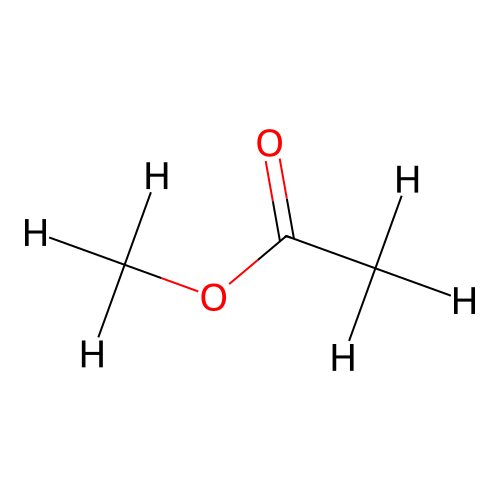

In [18]:
rdmol_smiles

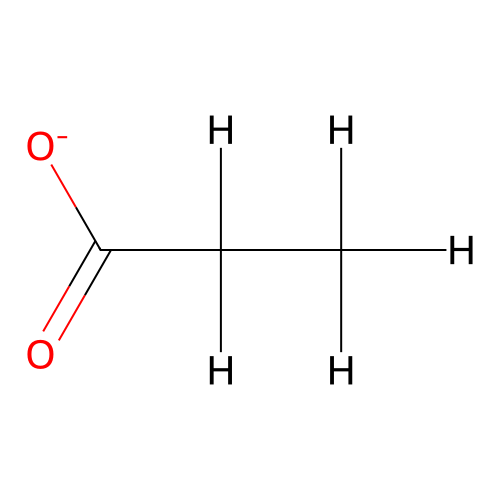

In [19]:
rdmol_iupac

### Connectivity mismatch (nx)

`nx_isomorphic == False` means the reference SMILES describes a **structurally different compound** than what is in the XYZ file — not just a bond-order disagreement, but a different molecular graph at the element level.

A subset of these are expected: some XYZ files in MNSol are known to not correspond to the named chemical (`wrong_xyz`). The code below reports:
1. how many molecules/systems fall into that known bad-XYZ category, and
2. how many molecules/systems remain after excluding that category.

In [20]:
wrong_xyz = ['diethyl4-nitrophenylthiophosphonate', 'dimethyl5-(4-chloro)bicyclo[3.2.0]heptylphosphate', "n-undecane", 
             "3-(4-methoxy-6-methyl-1,3,5-triazin-2-ylcarbamoylsulfamoyl)thiophene-2-carboxylicacid(thifensulfuron)", 
             "a-[(4,6-dimethoxypyrimidin-2-ylcarbamoyl)sulfamoyl]-o-toluicacid(bensulfuron)", "1,1-dichloro-2,2-difluoroethylmethylether", 
             "isobutanol", "dimethyl2,4,5-trichlorophenylthiophosphate"]


In [21]:
df_nx_false = df.filter(
    (pl.col("nx_isomorphic") == False)
    & (pl.col("solute_in_smiles_dict") == True)
    & (pl.col("solvent_in_smiles_dict") == True)
    & (pl.col("solute_name_change") == False)
    & (pl.col("xyz_to_rdkit_result") == "success")
    & (pl.col("formula_consistent") == True)
)

df_nx_known_xyz = df_nx_false.filter(
    pl.col("solute_name").is_in(wrong_xyz)
)

df_nx_remaining = df_nx_false.filter(
    ~pl.col("solute_name").is_in(wrong_xyz)
)

known_mols = set(df_nx_known_xyz["solute_name"].to_list())
remaining_mols = set(df_nx_remaining["solute_name"].to_list())

print(f"Known bad-XYZ mismatches: {len(known_mols)} molecules, {len(df_nx_known_xyz)} systems")
print(f"Remaining connectivity mismatches: {len(remaining_mols)} molecules, {len(df_nx_remaining)} systems")

print("Remaining MNSol entry numbers:", [int(x.split("-")[1]) for x in df_nx_remaining["key"].to_list()])
remaining_mols

Known bad-XYZ mismatches: 3 molecules, 4 systems
Remaining connectivity mismatches: 0 molecules, 0 systems
Remaining MNSol entry numbers: []


Known bad-XYZ mismatches: 3 molecules, 4 systems
Remaining connectivity mismatches: 0 molecules, 0 systems
Remaining MNSol entry numbers: []


set()

### Issue 4 — Resonance Structure Mismatch (Bond Order / Formal Charge)

`offmol_isomorphic == False` while `nx_isomorphic == True` means the reference SMILES and the `tmos`-perceived molecule have **identical element-level connectivity** but differ in bond orders or formal charges. Both are valid Lewis structures of the same compound — e.g., a nitro group written as `[N+](=O)[O-]` vs `N(=O)=O`. These entries are chemically correct but require bond-order harmonisation before being used with a force field or atom mapper.

In [23]:
df_offmol_iso = df.filter(
    (pl.col("offmol_isomorphic") == False)
    & (pl.col("nx_isomorphic") == True)   # same connectivity — only bond order / charge differs
    & (pl.col("solute_name_change") == False)
    & (pl.col("solute_in_smiles_dict") == True)
    & (pl.col("solvent_in_smiles_dict") == True)
    & (~pl.col("solute_name").is_in(wrong_xyz))
)

solute_names = set(df_offmol_iso["solute_name"].to_list())
print(f"Resonance mismatches: {len(solute_names)} molecules, {len(df_offmol_iso)} systems")
solute_names

Resonance mismatches: 0 molecules, 0 systems


set()